# ThF⁺ X ³Δ₁ with `heff`

²³²Th¹⁹F⁺, X ³Δ₁, v = 0, J = 1–4, Hund's case (c) basis |J, Ω = ±1, F, m_F⟩ —
96 states, block-diagonal in signed m_F for collinear static fields.

`heff` writes a Hamiltonian as `H = Σ_k c_k M_k`. The term matrices `M_k` are
built once per basis block; a parameter change is a weighted resum, a whole
sweep is one `np.tensordot` plus a batched `eigh`, and every derivative is
exact (`∂H/∂knob = Σ M_k`, Hellmann–Feynman) rather than a finite difference.

This notebook builds the basis, inspects the term catalogue and the assembled
Hamiltonian, diagonalises it, labels the eigenstates by parity and e/f, maps
the Stark and Zeeman structure, extracts g-factors, induced dipoles and the
Ω-doublet Δg, shows the PT-odd shift, lists the J = 1 → 2 E1 lines, and closes
with a 200-point parameter-set sweep done as one resum and one batched `eigh`.

This is an advanced, native-API tutorial: it exposes the basis, term matrices,
and observables used by `heff`, rather than hiding them behind a convenience
wrapper. Start with the repository [README](../README.md), including its TOML
model quickstart, and use the separate [three-isotope field plots](../results/thf-fields-2026-09-08/README.md)
for the broader J = 1–3 exploratory scans.

Physics source: [HAM](../docs/thf-plus-x3delta1-effective-hamiltonian.md).
Every matrix element carries its citation in `term.cite`. The calculations
illustrate the selected effective Hamiltonian and its inputs. Software tests
check implementation identities and regressions; they do not establish the
physical truth or completeness of this model.

Conventions in force (all defaults, all documented forks): n̂ from F to Th
(JILA), e/f by Brown 1975, Zeeman `+G∥ μ_B (J·n̂)(n̂·B)`, `E = −g μ_B B m_F`,
`Δg = g^u − g^ℓ`, eEDM with no Leanhardt ½.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import heff
from heff import (block_by_mF, build_term_matrices, ctx_from, eigh_batch,
                  enumerate_kets, expectation, g_factors, hamiltonian,
                  hamiltonian_batch, label_lines, line_strengths,
                  pair_differential, parity_operator, sweep,
                  sweep_coefficients, terms_for_case, thf_spec, thf_v1)

np.set_printoptions(precision=6, suppress=True, linewidth=120)
plt.rcParams['figure.dpi'] = 90

pset = thf_v1()
print(pset.table())
print()
for key, val in pset.conventions.stamp().items():
    print(f"  {key:<15s} {val}")

symbol             value  unit         status      source
A_par              -20.1  MHz          measured    Ng 2022 Table I p.5
B0              7274.333  MHz          measured    Ng 2022 SII B p.2 (4B = 29.09733(4) GHz); Ng thesis S4.1.1 p.78
D0                 3.897  kHz          measured    Gresh 2016 Table 1, X3Delta1 D'' column (1.30(4)e-7 cm-1)
E_eff                 35  GV/cm        ab-initio   Ng thesis Eq. C.8 discussion p.322 (JILA adopts ~35); Skripnikov & Titov 2015 give 37.3(7 %), Denis 2015 35.2
G_par            0.04756               derived     Ng thesis p.87 (0.048(2) for g_F < 0); reproduces |g_F=3/2| = 0.0149 exactly -- [HAM] S3
W_TP                  50  kHz          ab-initio   Skripnikov & Titov 2015 Table II p.8 (+-7 %)
c_I                   20  kHz          estimate    [HAM] S2.6: B&C Table 8.12 c2(19F, CsF) = 15.1 kHz at B_v = 0.183782 cm-1, scaled linearly in B
d_e                    0               held-fixed  
d_mf                3.37  D            measured    

## 1. The basis

`thf_spec()` is the frozen state spec; `enumerate_kets` is the only code that
knows the coupling case. The per-block dimensions are computed here, not
asserted from the document.

In [2]:
spec = thf_spec()
kets = enumerate_kets(spec)
blocks = block_by_mF(kets)
print(f"{len(kets)} states, {len(blocks.labels)} signed-m_F blocks ({blocks.kind})")
print({lab: len(ix) for lab, ix in sorted(blocks.index.items())})
print()
print("first four kets (J, Omega, F, m_F):")
print(kets[:4])

96 states, 10 signed-m_F blocks (signed_mF)
{-4.5: 2, -3.5: 6, -2.5: 10, -1.5: 14, -0.5: 16, 0.5: 16, 1.5: 14, 2.5: 10, 3.5: 6, 4.5: 2}

first four kets (J, Omega, F, m_F):
[(1., -1., 0.5, -0.5) (1.,  1., 0.5, -0.5) (1., -1., 0.5,  0.5) (1.,  1., 0.5,  0.5)]


## 2. The term catalogue

Adding a term is one decorated function plus one parameter entry. Each carries
its declared selection rules as data (a gate checks the formula against them)
and its primary-source citation. The coefficient of a term is the product of
its knob symbols, so `stark_z` is off whenever `E_z = 0` and the two PT-odd
terms are off whenever `d_e = k_TP = 0` — which is their default.

In [3]:
for t in terms_for_case('c'):
    print(f"{t.name:28s} param={str(t.param):22s} dJ={t.rules.dJ} dOm={t.rules.dOm} dF={t.rules.dF}")
    print(f"{'':28s} {t.cite[:100]}...")

centrifugal                  param=('D0',)                dJ=(0,) dOm=(0.0,) dF=(0,)
                             Ng thesis Eq. C.7d p.322: -D [J(J+1)]^2. The minus lives in the matrix, so D0 stays positive (3.897 ...
hyperfine_A_par              param=('A_par',)             dJ=(0,) dOm=(0.0,) dF=(0,)
                             Ng thesis Eq. C.2 p.319 = B&C Eq. (9.50) PDF p.636 / book p.604: A_par [F(F+1) - I(I+1) - J(J+1)] / ...
hyperfine_A_par_dJ1          param=('A_par',)             dJ=(-1, 1) dOm=(0.0,) dF=(0,)
                             B&C Eq. (9.51) PDF p.636 / book p.604, <eta,J|H_hf|eta,J-1> = -{a Lambda + (b_F + (2/3)c) Sigma} (J^...
omega_doubling               param=('omega_ef',)          dJ=(0,) dOm=(-2.0, 2.0) dF=(0,)
                             Ng thesis Eq. C.3 p.319, sign transposed to the heff ket phase (-1)^(J-S+s); see docs/open-questions...
pt_odd_edm                   param=('d_e', 'E_eff')       dJ=(0,) dOm=(0.0,) dF=(0,)
                             Ng the

## 3. Term matrices for two blocks

Built once each. Every Hamiltonian after this is a weighted sum — one BLAS
call per parameter set instead of a fresh sweep of Wigner symbols.

Two blocks are used in what follows, and the choice matters for what you see:

- **m_F = +3/2** (dim 14) — the *stretched* doublet. At J = 1 only F = 3/2 can
  carry m_F = 3/2, so the Ω-doublet is clean and the closed forms for the Stark
  shift and the g-factor apply exactly. This is the doublet the JILA eEDM
  measurement uses, and it is what §7–§14 work in.
- **m_F = +1/2** (dim 16) — carries **both** F = 1/2 and F = 3/2 at J = 1, so
  it is the block that shows the axial hyperfine structure. §4–§6, the line
  list in §15 and the parameter sweep in §16 use it.

`tm.mats` is a tuple of per-term (d, d) matrices, each in its own dtype;
promotion to complex happens at assembly and only for terms that are active.

In [4]:
ctx = ctx_from(spec, pset)
sub = kets[blocks.index[1.5]]        # stretched, m_F = +3/2
sub_h = kets[blocks.index[0.5]]      # m_F = +1/2, both F at J = 1
tm = build_term_matrices(sub, ctx)
tm_h = build_term_matrices(sub_h, ctx)

print(f"m_F=+3/2: {len(tm.mats)} term matrices of shape {tm.mats[0].shape}, "
      f"built in {tm.manifest['build_seconds']:.2f} s")
print(f"m_F=+1/2: {len(tm_h.mats)} term matrices of shape {tm_h.mats[0].shape}, "
      f"built in {tm_h.manifest['build_seconds']:.2f} s")
print("terms:", tm.names)
print("spec_hash:", tm.manifest['spec_hash'][:16], " wigner:", tm.manifest['wigner_version'])

m_F=+3/2: 11 term matrices of shape (14, 14), built in 0.34 s
m_F=+1/2: 11 term matrices of shape (16, 16), built in 0.01 s
terms: ('centrifugal', 'hyperfine_A_par', 'hyperfine_A_par_dJ1', 'omega_doubling', 'pt_odd_edm', 'pt_odd_scalar_pseudoscalar', 'rotation', 'spin_rotation_cI', 'stark_z', 'zeeman_Gpar', 'zeeman_nuclear')
spec_hash: 7dbc3cce64db67fb  wigner: 1.14.0


Energies are quoted throughout relative to the J = 1 rotational energy
`2B₀`, so what is on screen is the hyperfine and Ω-doubling structure rather
than 14.5 GHz of rotation. The 4 × 4 corner below is the J = 1 and J = 2,
F = 3/2 part of the m_F = +3/2 Hamiltonian at zero field.

In [5]:
OFF = 2 * pset.value('B0')
H0 = hamiltonian(tm, pset, {'E_z': 0.0, 'B_z': 0.0})
print("kets 0-3:", sub[:4])
print()
print(H0[:4, :4] - OFF * np.eye(4))
print()
A, cI, D0, wef = (pset.value(s) for s in ('A_par', 'c_I', 'D0', 'omega_ef'))
print(f"H[0,0] - 2B0 = {H0[0, 0] - OFF:+.6f} MHz   "
      f"A/4 + c_I/2 - 4 D0 = {A / 4 + cI / 2 - 4 * D0:+.6f}   (hyperfine + spin-rotation + centrifugal)")
print(f"H[0,1]       = {H0[0, 1]:+.6f} MHz   "
      f"-w_ef J(J+1)/4 = {-wef * 1 * 2 / 4:+.6f}   (Omega-doubling, J = 1)")
print(f"H[2,3]       = {H0[2, 3]:+.6f} MHz   "
      f"-w_ef J(J+1)/4 = {-wef * 2 * 3 / 4:+.6f}   (Omega-doubling, J = 2)")
print(f"H[0,2]       = {H0[0, 2]:+.6f} MHz   "
      f"(the dJ = +-1 axial hyperfine, B&C Eq. 9.51 -- same A_par, no free parameter)")

kets 0-3: [(1., -1., 1.5, 1.5) (1.,  1., 1.5, 1.5) (2., -1., 1.5, 1.5) (2.,  1., 1.5, 1.5)]

[[   -5.030588    -2.645       -8.703555     0.      ]
 [   -2.645       -5.030588     0.           8.703555]
 [   -8.703555     0.       29102.184708    -7.935   ]
 [    0.           8.703555    -7.935    29102.184708]]

H[0,0] - 2B0 = -5.030588 MHz   A/4 + c_I/2 - 4 D0 = -5.030588   (hyperfine + spin-rotation + centrifugal)
H[0,1]       = -2.645000 MHz   -w_ef J(J+1)/4 = -2.645000   (Omega-doubling, J = 1)
H[2,3]       = -7.935000 MHz   -w_ef J(J+1)/4 = -7.935000   (Omega-doubling, J = 2)
H[0,2]       = -8.703555 MHz   (the dJ = +-1 axial hyperfine, B&C Eq. 9.51 -- same A_par, no free parameter)


## 4. Zero-field structure — hyperfine and Ω-doubling

This runs in the **m_F = +1/2** block, which is the one that carries both
F = 1/2 and F = 3/2 at J = 1. Two intervals are visible in the four J = 1
levels: the Ω-doublet splitting `ω_ef J(J+1)/2 = 5.29 MHz` at J = 1, and the
axial hyperfine interval, whose leading closed form is `(3/4)|A∥| = 15.075 MHz`
with F = J − ½ lying *above* F = J + ½ because A∥ < 0. The model value comes
out slightly smaller because `c_I` and the ΔJ = ±1 hyperfine also contribute;
the cell prints both so the difference is visible rather than asserted.

In [6]:
def gen_state_str(k):
    return f"|J={k['J']:.0f}, Om={k['Om']:+.0f}, F={k['F']:.1f}, mF={k['mF']:+.1f}>"


def write_state(kets_, w, v, n=6, thresh=0.05):
    for s in range(min(n, len(w))):
        amps = v[:, s]
        big = np.argsort(-np.abs(amps))[:3]
        comp = '  '.join(f"{amps[b]:+.3f} {gen_state_str(kets_[b])}"
                         for b in big if abs(amps[b]) > thresh)
        print(f"E[{s:2d}] = {w[s]:14.6f} MHz   {comp}")


H0h = hamiltonian(tm_h, pset, {'E_z': 0.0, 'B_z': 0.0})
w0, v0 = np.linalg.eigh(H0h)
write_state(sub_h, w0 - OFF, v0, n=6)

dom = sub_h[np.argmax(np.abs(v0), axis=0)]
i32 = np.flatnonzero((dom['J'] == 1) & (dom['F'] == 1.5))
i12 = np.flatnonzero((dom['J'] == 1) & (dom['F'] == 0.5))
print()
print(f"Omega-doublet splitting, J = 1, F = 3/2 : {np.diff(w0[i32])[0]:.6f} MHz"
      f"   (w_ef J(J+1)/2 = {wef:.6f})")
print(f"hyperfine interval F = 1/2 minus F = 3/2: {w0[i12].mean() - w0[i32].mean():.6f} MHz"
      f"   ((3/4)|A_par| = {0.75 * abs(A):.6f}, and -(3/2) c_I = {-1.5 * cI:+.6f})")

E[ 0] =      -7.678190 MHz   +0.707 |J=1, Om=+1, F=1.5, mF=+0.5>  +0.707 |J=1, Om=-1, F=1.5, mF=+0.5>
E[ 1] =      -2.388191 MHz   +0.707 |J=1, Om=-1, F=1.5, mF=+0.5>  -0.707 |J=1, Om=+1, F=1.5, mF=+0.5>
E[ 2] =       7.369412 MHz   -0.707 |J=1, Om=-1, F=0.5, mF=+0.5>  -0.707 |J=1, Om=+1, F=0.5, mF=+0.5>
E[ 3] =      12.659412 MHz   -0.707 |J=1, Om=-1, F=0.5, mF=+0.5>  +0.707 |J=1, Om=+1, F=0.5, mF=+0.5>
E[ 4] =   29085.922652 MHz   +0.707 |J=2, Om=+1, F=2.5, mF=+0.5>  +0.707 |J=2, Om=-1, F=2.5, mF=+0.5>
E[ 5] =   29094.252311 MHz   +0.707 |J=2, Om=-1, F=1.5, mF=+0.5>  +0.707 |J=2, Om=+1, F=1.5, mF=+0.5>

Omega-doublet splitting, J = 1, F = 3/2 : 5.289998 MHz   (w_ef J(J+1)/2 = 5.290000)
hyperfine interval F = 1/2 minus F = 3/2: 15.047603 MHz   ((3/4)|A_par| = 15.075000, and -(3/2) c_I = -0.030000)


## 5. Parity and e/f labels

At zero field the eigenstates are Ω-doublet superpositions with definite
parity, and `⟨P⟩` below comes out at exactly ±1. The e/f label follows Brown
1975 (`ef_rule='brown1975'`); applying the thesis rule `P = (−1)^{J−S−ℓ}` to
S = 1 would invert every label ([HAM] §2.3 TRAP, OPEN-2). `label_lines` does
the labelling — the labels below are read off the eigenvectors, not typed in.

The upper component of each doublet has parity `(−1)^J`, i.e. e lies above f
uniformly in J. That ordering is **OQ-A** in `docs/open-questions.md`: it is
what Ng 2022 Fig. 2 and Gresh 2016's `k″ < 0` show, and reproducing it is why
`omega_doubling` carries `−ω_ef J(J+1)/4` rather than Ng Eq. C.3's literal
`(−1)^J` prefactor. The splitting magnitude is the same either way. This
ordering was confirmed by Arian on 2026-09-05; OQ-A is closed.

In [7]:
P = parity_operator(sub_h, ctx.S, ell=0.0, s=0.0)
labels0 = label_lines(sub_h, v0, ctx.S, rule=pset.conventions.ef_rule, ell=0.0, s=0.0)
for s in range(8):
    lab = labels0[s]
    par = float(v0[:, s] @ P @ v0[:, s])
    print(f"E[{s}] = {w0[s] - OFF:13.6f} MHz   <P> = {par:+.4f}   "
          f"J = {lab['J']:.0f}, F = {lab['F']:.1f}, {lab['ef']}")

E[0] =     -7.678190 MHz   <P> = +1.0000   J = 1, F = 1.5, f
E[1] =     -2.388191 MHz   <P> = -1.0000   J = 1, F = 1.5, e
E[2] =      7.369412 MHz   <P> = +1.0000   J = 1, F = 0.5, f
E[3] =     12.659412 MHz   <P> = -1.0000   J = 1, F = 0.5, e
E[4] =  29085.922652 MHz   <P> = -1.0000   J = 2, F = 2.5, f
E[5] =  29094.252311 MHz   <P> = -1.0000   J = 2, F = 1.5, f
E[6] =  29101.792650 MHz   <P> = +1.0000   J = 2, F = 2.5, e
E[7] =  29110.122310 MHz   <P> = +1.0000   J = 2, F = 1.5, e


## 6. Selecting eigenstates by quantum number

The analogue of the RaF tutorial's `select_q`: label each eigenvector by its
dominant basis ket, then filter. This is a display convenience — a state that
is not dominated by one (J, F) still gets a label, just a less useful one.

In [8]:
def dominant(kets_, v):
    return kets_[np.argmax(np.abs(v), axis=0)]


def select_q(kets_, v, **q):
    dom_ = dominant(kets_, v)
    mask = np.ones(v.shape[1], bool)
    for key, val in q.items():
        mask &= (dom_[key] == val)
    return np.flatnonzero(mask)


for F in (1.5, 0.5):
    sel = select_q(sub_h, v0, J=1.0, F=F)
    print(f"J = 1, F = {F}: indices {sel}, E - 2B0 = {(w0[sel] - OFF).round(4)} MHz")
print(f"J = 2 states in this block: {select_q(sub_h, v0, J=2.0)}")

J = 1, F = 1.5: indices [0 1], E - 2B0 = [-7.6782 -2.3882] MHz
J = 1, F = 0.5: indices [2 3], E - 2B0 = [ 7.3694 12.6594] MHz
J = 2 states in this block: [4 5 6 7]


## 7. Stark map

Back to the stretched **m_F = +3/2** block. The Ω-doublet polarises where
`γ_F m_F d_mf E = ω_ef/2`; with `γ_{F=3/2}(J=1) = 1/3` that is ≈ 3.1 V/cm. Well
above it the two components separate linearly, and at the JILA field of
60 V/cm the half-splitting is ≈ 51 MHz. The two-level closed form
`√((γ_F m_F d_mf E)² + (ω_ef/2)²)` is printed next to the model value; they
differ by the J-mixing the two-level form leaves out.

The two panels are separated because J = 2 sits 4B₀ ≈ 29 GHz above J = 1: put
them on one axis and the hyperfine and Stark structure both vanish into the
line width. Each panel is referred to its own rotational origin.

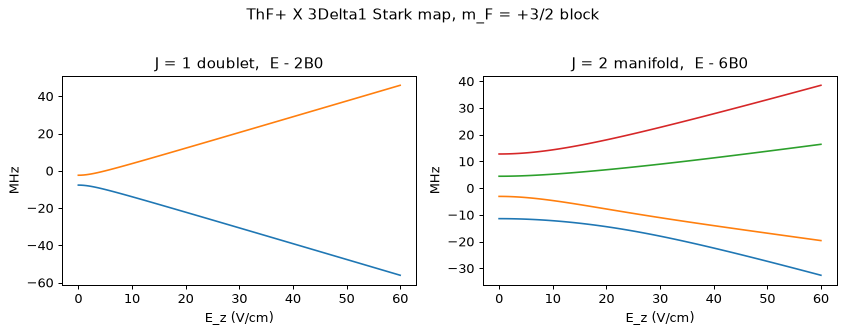

crossover field gam_F m_F d_mf E = w_ef/2 : 3.118 V/cm
half-splitting at 60 V/cm, model        : 50.9741 MHz
                two-level closed form   : 50.9636 MHz
active terms in this sweep: ('centrifugal', 'hyperfine_A_par', 'hyperfine_A_par_dJ1', 'omega_doubling', 'rotation', 'spin_rotation_cI', 'stark_z')
order = 'energy', gauge = 'none', reference index = 0


In [9]:
E = np.linspace(0.0, 60.0, 121)
res_E = sweep(tm, pset, {'E_z': E, 'B_z': np.zeros_like(E)})

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.6))
for s in (0, 1):
    ax[0].plot(E, res_E.evals[:, s] - OFF, lw=1.3)
ax[0].set_title('J = 1 doublet,  E - 2B0')
for s in range(2, 6):
    ax[1].plot(E, res_E.evals[:, s] - 6 * pset.value('B0'), lw=1.3)
ax[1].set_title('J = 2 manifold,  E - 6B0')
for a in ax:
    a.set_xlabel('E_z (V/cm)')
    a.set_ylabel('MHz')
fig.suptitle('ThF+ X 3Delta1 Stark map, m_F = +3/2 block', y=1.02)
plt.tight_layout()
plt.show()

gam = lambda J, F, I=0.5: (J * (J + 1) + F * (F + 1) - I * (I + 1)) / (2 * F * (F + 1) * J * (J + 1))
d_mf = pset.value('d_mf')
Ecross = (wef / 2) / (gam(1, 1.5) * 1.5 * d_mf)
half = 0.5 * (res_E.evals[-1, 1] - res_E.evals[-1, 0])
two_level = np.hypot(gam(1, 1.5) * 1.5 * d_mf * 60.0, wef / 2)
print(f"crossover field gam_F m_F d_mf E = w_ef/2 : {Ecross:.3f} V/cm")
print(f"half-splitting at 60 V/cm, model        : {half:.4f} MHz")
print(f"                two-level closed form   : {two_level:.4f} MHz")
print("active terms in this sweep:", res_E.active_terms)
print(f"order = {res_E.order!r}, gauge = {res_E.gauge!r}, reference index = {res_E.reference}")

## 8. Zeeman maps, at zero field and at the operating field

Plotted as the shift from B = 0, so the Zeeman slope itself is visible rather
than the 100 MHz of Stark splitting it sits on.

At E = 0 the Zeeman shift is even in Ω, so the two doublet components move
together: `g^u = g^ℓ` exactly, and the right panel is identically zero. The
whole differential g-factor of §12 therefore has to come from the E field —
at 60 V/cm the two slopes differ by about 4.5 parts in a thousand, which is
`Δg/ḡ`, twice the `δg/g` of §12.

E_z =   0.0 V/cm, level 0: dE over 0-5 G = +0.156430 MHz
E_z =   0.0 V/cm, level 1: dE over 0-5 G = +0.156430 MHz


E_z =  60.0 V/cm, level 0: dE over 0-5 G = +0.156778 MHz
E_z =  60.0 V/cm, level 1: dE over 0-5 G = +0.156081 MHz


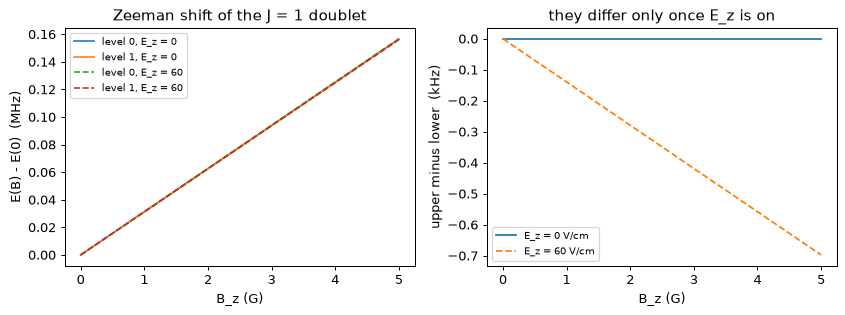

|g| mu_B B m_F at B = 5 G, |g| = 0.0149, m_F = 3/2: 0.156408 MHz


In [10]:
B = np.linspace(0.0, 5.0, 101)
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.6))
for Ez, ls in ((0.0, '-'), (60.0, '--')):
    r = sweep(tm, pset, {'E_z': np.full_like(B, Ez), 'B_z': B})
    shift = r.evals - r.evals[0]
    for s in (0, 1):
        ax[0].plot(B, shift[:, s], ls, lw=1.3, label=f'level {s}, E_z = {Ez:g}')
        print(f"E_z = {Ez:5.1f} V/cm, level {s}: dE over 0-5 G = {shift[-1, s]:+.6f} MHz")
    ax[1].plot(B, (shift[:, 1] - shift[:, 0]) * 1e3, ls, lw=1.4,
               label=f'E_z = {Ez:g} V/cm')
ax[0].set_ylabel('E(B) - E(0)  (MHz)')
ax[0].set_title('Zeeman shift of the J = 1 doublet')
ax[1].set_ylabel('upper minus lower  (kHz)')
ax[1].set_title('they differ only once E_z is on')
for a in ax:
    a.set_xlabel('B_z (G)')
    a.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"|g| mu_B B m_F at B = 5 G, |g| = 0.0149, m_F = 3/2: "
      f"{0.0149 * heff.MU_B * 5 * 1.5:.6f} MHz")

## 9. A 2D (E, B) map

One `sweep` call over 2501 field points. The knob arrays are broadcast, the
Hamiltonians come out of a single `tensordot`, and `eigh` runs in chunks sized
to a memory budget. What is mapped is again the Zeeman part alone —
`E(E_z, B_z) − E(E_z, 0)` — because the Stark shift is three orders of
magnitude larger and would be the only thing visible otherwise. What is left is
linear in B and, at this colour scale, flat in E_z — g moves by only a fraction
of a percent across 0–60 V/cm for this level, which is why §14 gives the J = 1
pair a second, fractional-change panel where that sub-percent, opposite-signed
motion is resolved. The cell prints the size of that residual E dependence.

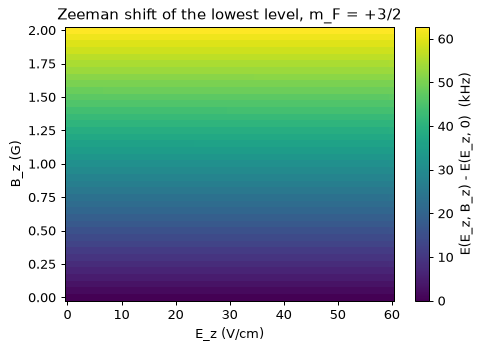

2501 field points x 14 levels, eigenvectors kept: (2501, 14, 14)
Zeeman shift at B_z = 2 G:  62.5721 kHz at E_z = 0,  62.7113 kHz at E_z = 60 V/cm  (+0.223 %)


In [11]:
Eg, Bg = np.meshgrid(np.linspace(0, 60, 61), np.linspace(0, 2, 41), indexing='ij')
res2 = sweep(tm, pset, {'E_z': Eg.ravel(), 'B_z': Bg.ravel()}, chunk=512)
lvl = res2.evals[:, 0].reshape(Eg.shape)
zeeman = (lvl - lvl[:, :1]) * 1e3        # shift from B_z = 0, in kHz

plt.figure(figsize=(5.5, 4))
plt.pcolormesh(Eg, Bg, zeeman, shading='auto')
plt.colorbar(label='E(E_z, B_z) - E(E_z, 0)  (kHz)')
plt.xlabel('E_z (V/cm)')
plt.ylabel('B_z (G)')
plt.title('Zeeman shift of the lowest level, m_F = +3/2')
plt.tight_layout()
plt.show()
print(f"{res2.evals.shape[0]} field points x {res2.evals.shape[1]} levels, "
      f"eigenvectors kept: {res2.evecs.shape}")
print(f"Zeeman shift at B_z = 2 G:  {zeeman[0, -1]:.4f} kHz at E_z = 0,  "
      f"{zeeman[-1, -1]:.4f} kHz at E_z = 60 V/cm  "
      f"({(zeeman[-1, -1] / zeeman[0, -1] - 1) * 100:+.3f} %)")

## 10. Levels at an arbitrary field

In [12]:
def display_levels(tm_, pset_, knobs, n=6):
    H = hamiltonian(tm_, pset_, knobs)
    w, v = np.linalg.eigh(H)
    Pop = parity_operator(tm_.kets, ctx.S, ell=0.0, s=0.0)
    print("  #        E - 2B0 (MHz)   <P>     dominant ket")
    for s in range(n):
        par = float(np.real(np.vdot(v[:, s], Pop @ v[:, s])))
        dom_ = tm_.kets[np.argmax(np.abs(v[:, s]))]
        print(f" {s:2d}   {w[s] - OFF:16.6f}  {par:+.3f}   {gen_state_str(dom_)}")


display_levels(tm, pset, {'E_z': 24.0, 'B_z': 1.0})

  #        E - 2B0 (MHz)   <P>     dominant ket
  0         -25.543677  +0.129   |J=1, Om=+1, F=1.5, mF=+1.5>
  1          15.522782  -0.129   |J=1, Om=-1, F=1.5, mF=+1.5>
  2       29081.656928  -0.625   |J=2, Om=+1, F=2.5, mF=+1.5>
  3       29088.231090  -0.639   |J=2, Om=+1, F=1.5, mF=+1.5>
  4       29105.032609  +0.741   |J=2, Om=-1, F=2.5, mF=+1.5>
  5       29117.227858  +0.524   |J=2, Om=-1, F=1.5, mF=+1.5>


## 11. g-factors and induced dipoles — exact, not finite differences

`g = −(∂E/∂B_z)/(μ_B m_F)` and `d_eff = −∂E/∂E_z`, both from one
Hellmann–Feynman kernel: `∂H/∂knob` is already in the catalogue as a sum of
term matrices, so no field step is chosen and no differencing noise enters.

At zero field the closed form is `g_F = −G∥ γ_F + g_N (μ_N/μ_B) κ_F` — Ng
Eq. C.6's relation, the same as Petrov Eqs. 2–3 — and `d_eff = 0` because the
unpolarised doublet has no space-fixed dipole. At 60 V/cm `d_eff` approaches
the fully polarised `γ_F m_F d_mf`.

In [13]:
gam_ = gam(1, 1.5)
kap = lambda J, F, I=0.5: (F * (F + 1) - J * (J + 1) + I * (I + 1)) / (2 * F * (F + 1))
closed = -pset.value('G_par') * gam_ + pset.value('g_N') * (heff.MU_N / heff.MU_B) * kap(1, 1.5)

res_g0 = g_factors(tm, pset, {'E_z': 0.0, 'B_z': 0.0}, ctx=ctx)
res_g60 = g_factors(tm, pset, {'E_z': 60.0, 'B_z': 0.0}, ctx=ctx)

print(f"model  g(J=1, F=3/2) = {res_g0['g'][0]:+.7f}   "
      f"({abs(res_g0['g'][0]) * heff.MU_B * 1e3:.3f} kHz/G)")
print(f"closed form          = {closed:+.7f}   ({abs(closed) * heff.MU_B * 1e3:.3f} kHz/G)")
print(f"measured |g|         =  0.0149(3)     (20.85 kHz/G)  [Ng 2022 Table I; sign not measured]")
print()
print(f"d_eff at   0 V/cm    = {res_g0['d_eff'][:4].round(6)} MHz/(V/cm)")
print(f"d_eff at  60 V/cm    = {res_g60['d_eff'][:4].round(6)} MHz/(V/cm)")
print(f"fully polarised gam_F m_F d_mf = {gam_ * 1.5 * d_mf:.6f} MHz/(V/cm)")
print()
print("m_F of this block:", res_g0['mF'], " conventions:", res_g0['conventions']['zeeman_energy'])

model  g(J=1, F=3/2) = -0.0149021   (20.857 kHz/G)
closed form          = -0.0148989   (20.853 kHz/G)
measured |g|         =  0.0149(3)     (20.85 kHz/G)  [Ng 2022 Table I; sign not measured]

d_eff at   0 V/cm    = [ 0. -0.  0. -0.] MHz/(V/cm)
d_eff at  60 V/cm    = [ 0.849058 -0.845499  0.530931  0.276353] MHz/(V/cm)
fully polarised gam_F m_F d_mf = 0.848249 MHz/(V/cm)

m_F of this block: 1.5  conventions: E_minus_g_muB_B_mF


## 12. The differential g-factor Δg

The two Stark components of the J = 1, F = 3/2 doublet acquire slightly
different J = 2 admixtures, so their g-factors differ. This is the eEDM
experiment's headline systematic, and the difference is a *named pair*, so it
goes through `pair_differential`, which keeps the sign and stamps which of the
two circulating definitions it used.

Note in advance ([HAM] §1.2): a single-electronic-state model is expected to
miss δg/g by about 15 %, because the ³Δ₂ coupling is not in the basis. Ng's own
32-level Ω = ±1 model gives −0.00223 against a measured −0.00255(6). That is a
finding, not a failure.

Delta = g^u - g^l  [Petrov arXiv:2503.02840 Eq. 18; Ng 2022 paper]


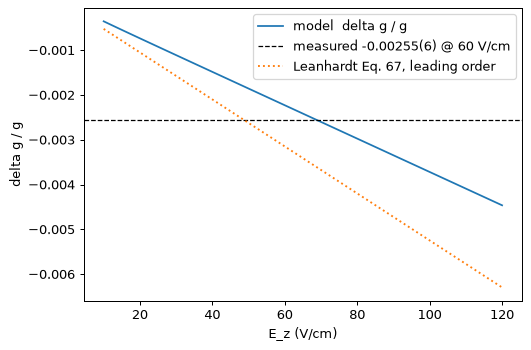

model  delta g / g at 60 V/cm = -0.00223
       Delta g   at 60 V/cm   = +6.644e-05
Ng 32-level model             = -0.00223      measured = -0.00255(6)
Leanhardt Eq. 67 at 60 V/cm   = -0.00315


In [14]:
Es = np.linspace(10.0, 120.0, 45)
g_all = np.array([g_factors(tm, pset, {'E_z': float(e), 'B_z': 0.0}, ctx=ctx)['g']
                  for e in Es])
gl, gu = g_all[:, 0], g_all[:, 1]          # lower and upper Stark doublet component
dg, label = pair_differential(gu, gl, pset.conventions)
gbar = 0.5 * (gu + gl)
print(label)

plt.figure(figsize=(6, 4))
plt.plot(Es, 0.5 * dg / gbar, lw=1.4, label='model  delta g / g')
plt.axhline(-0.00255, ls='--', c='k', lw=1, label='measured -0.00255(6) @ 60 V/cm')
plt.plot(Es, -9 * d_mf * Es / (40 * pset.value('B0')), ':',
         label='Leanhardt Eq. 67, leading order')
plt.xlabel('E_z (V/cm)')
plt.ylabel('delta g / g')
plt.legend()
plt.tight_layout()
plt.show()

print(f"model  delta g / g at 60 V/cm = {np.interp(60.0, Es, 0.5 * dg / gbar):+.5f}")
print(f"       Delta g   at 60 V/cm   = {np.interp(60.0, Es, dg):+.3e}")
print(f"Ng 32-level model             = -0.00223      measured = -0.00255(6)")
print(f"Leanhardt Eq. 67 at 60 V/cm   = {-9 * d_mf * 60 / (40 * pset.value('B0')):+.5f}")

## 13. PT-odd shifts

`H_PT = −(d_e E_eff + W_TP k_TP) Ω/|Ω|` — Ng Eq. C.8, no Leanhardt ½, which is
what `edm_factor='ng'` selects; the sign of Ω is fixed by `n_hat='F_to_Th'`,
i.e. n̂ points from F to Th. The observable in the experiment is
`f^BD = 2 d_e E_eff`.

Both PT-odd terms are off in `thf_v1()` (`d_e = k_TP = 0`), so nothing here
changes any energy above. What is plotted is the *matrix* the term contributes,
`−Ω/|Ω|`, evaluated as a first-order expectation value `⟨ψ|M|ψ⟩` on the Stark
eigenstates: it runs from 0 at zero field to ∓1 when the doublet is fully
polarised, and multiplying it by `d_e E_eff` gives the shift. Taking the shift
as an eigenvalue difference instead would put a 35 µHz number on top of a
14.5 GHz rotational energy — within a factor of ~30 of float64 resolution —
whereas the expectation value is clean.

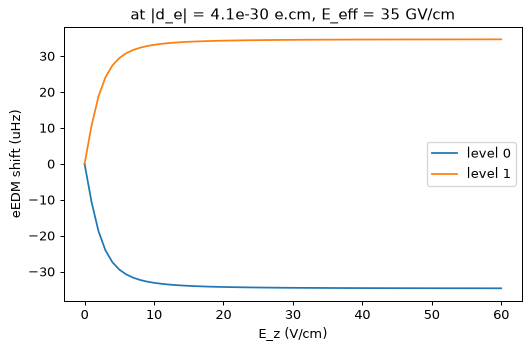

convention: edm_factor = 'ng', n_hat = 'F_to_Th' (n_hat points from F to Th)
<-Omega/|Omega|> at 60 V/cm, levels 0 and 1: [-0.99865  0.99865]   (at 0 V/cm: [-0.  0.])
d_e E_eff at the bound      = 34.7 uHz;   f^BD = 2 d_e E_eff = 69.4 uHz
W_TP k_TP at k_TP = 1e-9    = 50.0 uHz


In [15]:
M_edm = tm.mats[tm.names.index('pt_odd_edm')]        # the parameter-free -Omega/|Omega|
Ep = np.linspace(0.0, 60.0, 61)
rp = sweep(tm, pset, {'E_z': Ep, 'B_z': np.zeros_like(Ep)})
om = np.real(expectation(rp.evecs, M_edm))

d_e_bound = 4.1e-30                     # |d_e| 90% bound, Roussy 2023 (HfF+), e.cm
uHz = d_e_bound * pset.value('E_eff') * 1e12       # MHz -> uHz

plt.figure(figsize=(6, 4))
for s in (0, 1):
    plt.plot(Ep, om[:, s] * uHz, lw=1.4, label=f'level {s}')
plt.xlabel('E_z (V/cm)')
plt.ylabel('eEDM shift (uHz)')
plt.title('at |d_e| = 4.1e-30 e.cm, E_eff = 35 GV/cm')
plt.legend()
plt.tight_layout()
plt.show()

print(f"convention: edm_factor = {pset.conventions.edm_factor!r}, "
      f"n_hat = {pset.conventions.n_hat!r} (n_hat points from F to Th)")
print(f"<-Omega/|Omega|> at 60 V/cm, levels 0 and 1: {om[-1, :2].round(5)}   "
      f"(at 0 V/cm: {om[0, :2].round(5)})")
print(f"d_e E_eff at the bound      = {uHz:.1f} uHz;   f^BD = 2 d_e E_eff = {2 * uHz:.1f} uHz")
print(f"W_TP k_TP at k_TP = 1e-9    = {pset.value('W_TP') * 1e-9 * 1e12:.1f} uHz")

## 14. g-factor vs field

The same exact-derivative kernel, swept. Levels are ordered by energy at each
field point, so a label follows an energy slot rather than a character — the
two J = 1 components (0 and 1) never cross here, the J = 2 slots do rearrange.

The left panel plots all six levels on one g-factor axis, where the J = 1
pair's motion is sub-pixel — §9 already flagged this as a fraction of a
percent. The right panel isolates levels 0 and 1 and plots the fractional
change `(g − g(E_ref)) / |g(E_ref)|` relative to `E_ref = 10 V/cm` (the first
field point, past the low-field polarisation knee), which resolves the ∓0.4 %
opposite-signed motion that is Δg.

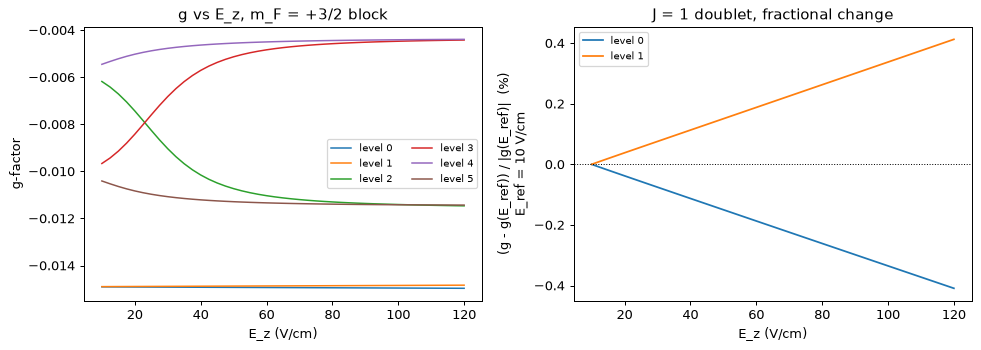

the two J = 1 components move by about 0.4 % across 10-120 V/cm, in opposite directions -- that opposite motion is Delta g:
  level 0: -0.0149074 -> -0.0149684   (-0.409 %)
  level 1: -0.0148968 -> -0.0148354   (+0.412 %)


In [16]:
E_ref = Es[0]                                        # 10 V/cm, first field point (past the polarisation knee)
g_ref = g_all[0, :2]
frac_pct = (g_all[:, :2] - g_ref) / np.abs(g_ref) * 100     # levels 0, 1 only

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for s in range(6):
    ax[0].plot(Es, g_all[:, s], lw=1.2, label=f'level {s}')
ax[0].set_xlabel('E_z (V/cm)')
ax[0].set_ylabel('g-factor')
ax[0].set_title('g vs E_z, m_F = +3/2 block')
ax[0].legend(fontsize=8, ncol=2)

for s in (0, 1):
    ax[1].plot(Es, frac_pct[:, s], lw=1.4, label=f'level {s}')
ax[1].axhline(0.0, ls=':', c='k', lw=0.8)
ax[1].set_xlabel('E_z (V/cm)')
ax[1].set_ylabel(f'(g - g(E_ref)) / |g(E_ref)|  (%)\nE_ref = {E_ref:.0f} V/cm')
ax[1].set_title('J = 1 doublet, fractional change')
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("the two J = 1 components move by about 0.4 % across 10-120 V/cm, "
      "in opposite directions -- that opposite motion is Delta g:")
for s in (0, 1):
    print(f"  level {s}: {g_all[0, s]:+.7f} -> {g_all[-1, s]:+.7f}   "
          f"({(g_all[-1, s] - g_all[0, s]) / abs(g_all[0, s]) * 100:+.3f} %)")

## 15. E1 line strengths, J = 1 → 2

Transition dipoles between two separately diagonalised m_F blocks:
m_F = +1/2 → +3/2, so the 3j selection rule `m_bra = m_ket + p` picks
p = −1. Amplitudes are summed over polarisation and then squared, so
intensity-borrowing paths interfere; strengths come out in units of `d_mf²`.

Evaluated at zero field, where parity is exact — and every line below connects
opposite parities, as E1 requires. Labels come from `label_lines`, which reads
the dominant (J, F) and the superposition parity off each eigenvector;
`line_strengths` never sees them, so labelling does not decide which
transitions get computed.

62 lines above 1e-6 of the strongest; 0 of them connect the same parity

J = 1 -> 2, offsets from 4B0 = 29097.330 MHz:
    -10.4471 MHz   S = 0.2501 d_mf^2   J=1 F=0.5 f (+1)  ->  J=2 F=1.5 f (-1)
     -3.7292 MHz   S = 0.1800 d_mf^2   J=1 F=1.5 f (+1)  ->  J=2 F=2.5 f (-1)
     +0.1329 MHz   S = 0.2501 d_mf^2   J=1 F=0.5 e (-1)  ->  J=2 F=1.5 e (+1)
     +4.6005 MHz   S = 0.0200 d_mf^2   J=1 F=1.5 f (+1)  ->  J=2 F=1.5 f (-1)
     +6.8508 MHz   S = 0.1800 d_mf^2   J=1 F=1.5 e (-1)  ->  J=2 F=2.5 e (+1)
    +15.1805 MHz   S = 0.0200 d_mf^2   J=1 F=1.5 e (-1)  ->  J=2 F=1.5 e (+1)


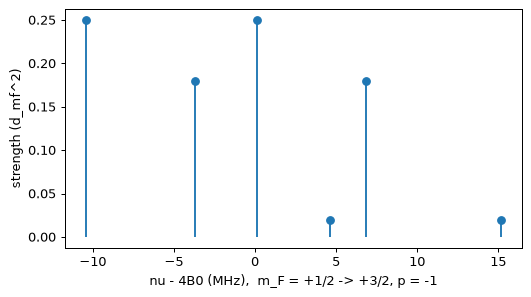

In [17]:
knobs0 = {'E_z': 0.0, 'B_z': 0.0}
wa, va = np.linalg.eigh(hamiltonian(tm_h, pset, knobs0))
wb, vb = np.linalg.eigh(hamiltonian(tm, pset, knobs0))
freqs, S = line_strengths(wa, va, sub_h, wb, vb, sub, ctx,
                          polarizations=(-1,), weights={-1: 1.0})
lab_a = label_lines(sub_h, va, ctx.S, rule=pset.conventions.ef_rule, ell=0.0, s=0.0)
lab_b = label_lines(sub, vb, ctx.S, rule=pset.conventions.ef_rule, ell=0.0, s=0.0)

mask = S > 1e-6 * S.max()
ia, ib = np.nonzero(mask)
same_parity = sum(1 for i, j in zip(ia, ib) if lab_a[i]['parity'] == lab_b[j]['parity'])
print(f"{mask.sum()} lines above 1e-6 of the strongest; "
      f"{same_parity} of them connect the same parity")

rows = sorted(((freqs[i, j], S[i, j], lab_a[i], lab_b[j]) for i, j in zip(ia, ib)
               if lab_a[i]['J'] == 1.0 and lab_b[j]['J'] == 2.0))
FOUR_B0 = 4 * pset.value('B0')
print(f"\nJ = 1 -> 2, offsets from 4B0 = {FOUR_B0:.3f} MHz:")
for f, s_, la, lb in rows:
    print(f"  {f - FOUR_B0:+10.4f} MHz   S = {s_:.4f} d_mf^2   "
          f"J=1 F={la['F']:.1f} {la['ef']} ({la['parity']:+d})  ->  "
          f"J=2 F={lb['F']:.1f} {lb['ef']} ({lb['parity']:+d})")

plt.figure(figsize=(6, 3.4))
plt.stem([f - FOUR_B0 for f, _, _, _ in rows], [s_ for _, s_, _, _ in rows], basefmt=' ')
plt.xlabel(f'nu - 4B0 (MHz),  m_F = +1/2 -> +3/2, p = -1')
plt.ylabel('strength (d_mf^2)')
plt.tight_layout()
plt.show()

## 16. A parameter-set sweep — 200 sets, one resum, one batched `eigh`

This is what the term-matrix catalogue buys, and what an engine that rebuilds
the Hamiltonian per parameter set cannot do. The coefficients are broadcast
into `c[200, n_terms]`, the Hamiltonians come out of a single `tensordot`, and
`eigh` runs once over the batch. Nothing is re-derived: `A_par` and `omega_ef`
are ordinary knobs, exactly like `E_z` and `B_z`.

Two observables from the same 200 diagonalisations, in the m_F = +1/2 block:
the J = 1, F = 3/2 Ω-doublet splitting, which tracks `ω_ef` and is flat in A∥;
and the J = 1 hyperfine interval, which tracks A∥ and is flat in `ω_ef`.

coefficient matrix : (200, 11)
batched Hamiltonians: (200, 16, 16)
eigenvalues         : (200, 16)


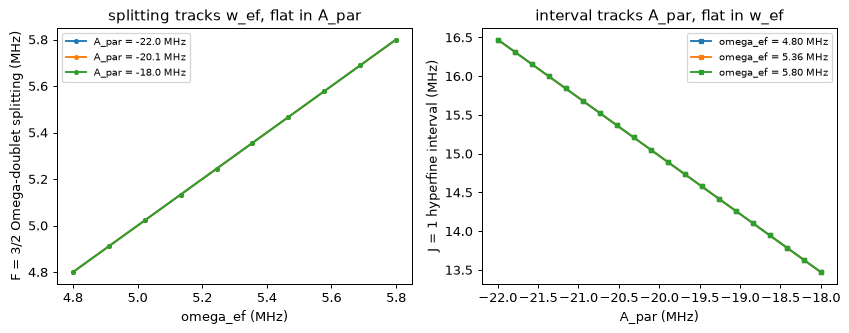

spread of the doublet splitting across all 20 A_par values at fixed w_ef: 6.80e-07 MHz
spread of the hyperfine interval across all 10 w_ef values at fixed A_par: 1.62e-10 MHz
hyperfine interval at A_par = -20 MHz  (closed form (3/4)|A| - (3/2)c_I = 14.9700): 14.9726 MHz


In [18]:
A_vals = np.linspace(-22.0, -18.0, 20)
w_vals = np.linspace(4.8, 5.8, 10)
Ag, Wg = np.meshgrid(A_vals, w_vals, indexing='ij')
zeros = np.zeros(Ag.size)

c = sweep_coefficients(tm_h, pset, {'A_par': Ag.ravel(), 'omega_ef': Wg.ravel(),
                                    'E_z': zeros, 'B_z': zeros})
print('coefficient matrix :', c.shape)
Hb = hamiltonian_batch(tm_h, c)
print('batched Hamiltonians:', Hb.shape)
wb2, _ = eigh_batch(Hb, chunk=256)
print('eigenvalues         :', wb2.shape)

doublet = (wb2[:, 1] - wb2[:, 0]).reshape(Ag.shape)
hf = (0.5 * (wb2[:, 2] + wb2[:, 3]) - 0.5 * (wb2[:, 0] + wb2[:, 1])).reshape(Ag.shape)

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.8))
for i in (0, 9, 19):
    ax[0].plot(w_vals, doublet[i], marker='o', ms=3, label=f'A_par = {A_vals[i]:.1f} MHz')
ax[0].set_xlabel('omega_ef (MHz)')
ax[0].set_ylabel('F = 3/2 Omega-doublet splitting (MHz)')
ax[0].set_title('splitting tracks w_ef, flat in A_par')
ax[0].legend(fontsize=8)
for j in (0, 5, 9):
    ax[1].plot(A_vals, hf[:, j], marker='s', ms=3, label=f'omega_ef = {w_vals[j]:.2f} MHz')
ax[1].set_xlabel('A_par (MHz)')
ax[1].set_ylabel('J = 1 hyperfine interval (MHz)')
ax[1].set_title('interval tracks A_par, flat in w_ef')
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"spread of the doublet splitting across all 20 A_par values at fixed w_ef: "
      f"{np.ptp(doublet[:, 0]):.2e} MHz")
print(f"spread of the hyperfine interval across all 10 w_ef values at fixed A_par: "
      f"{np.ptp(hf[0, :]):.2e} MHz")
print(f"hyperfine interval at A_par = -20 MHz  (closed form (3/4)|A| - (3/2)c_I = "
      f"{0.75 * 20 - 1.5 * cI:.4f}): {np.interp(-20.0, A_vals, hf[:, 0]):.4f} MHz")

## 17. What this model does and does not contain

**In** — nine Hamiltonian terms plus an opt-in PT-odd pair: rotation,
centrifugal distortion, Ω-doubling, axial hyperfine ΔJ = 0 and ΔJ = ±1 (one
parameter, A∥, for both), nuclear spin–rotation `c_I`, Stark, `+G∥` Zeeman,
nuclear Zeeman; then `pt_odd_edm` and `pt_odd_scalar_pseudoscalar`.

**Out, and why** — sizes from [HAM] §5:

- Ω = ±2, ±3 (³Δ₂, ³Δ₃): mixing ≤ 1.4 × 10⁻³, energy effect linear in J(J+1)
  and therefore absorbed into B₀; residual ≤ 38 Hz at J = 4. Costs 15 % of δg,
  which is the gap §12 shows.
- `e_Δ`, the hyperfine-dependent Ω-doubling: 1–10 kHz **estimate**, the only
  dropped term above the kHz line — **OPEN-8**.
- Parity-dependent Zeeman (`g_rS`, `g'_rS`): ≈ 1 kHz at 1 G; required for any
  zero-field Δg — **OPEN-10**.
- Rotational `g_r`: ≤ 0.6 % of g_F, absorbed into the fitted G∥ at J = 1, so
  the predicted g at J = 2–4 carries an unquantified ~1 % error — **OPEN-7**.
- Rotating-frame `ħω_rot F_x`: not a static-field term, and it breaks m_F
  blocking.

**Statuses that matter.** `c_I = 20 kHz` is an analogy-based sensitivity
estimate: its sign and accuracy in ThF⁺ are not established, and no universal
numeric uncertainty bound is assigned (**OPEN-6**). The sign of g_F is not
measured, only |g| (**OPEN-4**); E_eff is 35 vs 37.3 GV/cm across sources
(**OPEN-14**).

**Open questions** — `docs/open-questions.md`:

- **OQ-A**, the Ω-doubling sign and the parity of the upper doublet component
  (§5 above). Confirmed by Arian on 2026-09-05; closed, code as written.
- The **[HAM] §2.8 g_F table erratum**: the printed table reproduces at
  G∥ = 0.048, not at the 0.04756 in its own header. The code uses 0.04756,
  which is what the document's own numerical confirmation line and the measured
  |g| = 0.0149 require; §11 above shows that agreement.

`tests/` check kernel behavior and symmetry identities; comparisons to
published numbers are opt-in behind `HEFF_RUN_LITERATURE=1`. These checks
support software consistency, not a claim that the effective Hamiltonian is
physically complete. Design: [v1 specification](../docs/superpowers/specs/2026-09-05-heff-design.md).